# Boston Housing - Análisis exploratorio de datos y preprocesamiento

## Análisis exploratorio

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

project_root = Path.cwd().parent
load_dotenv(project_root / ".env")

SQLITE_PATH = project_root / os.environ.get("SQLITE_PATH", ".storage/data.db")
TABLE_NAME = "housing_data"

In [2]:
# Dependencias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from src.data.repository import load_data
from src.data.schema import FEATURE_COLUMNS, TARGET_COLUMN

In [3]:
# Carga inicial de datos
df = load_data(SQLITE_PATH, TABLE_NAME)
print("Tamaño:", df.shape)
df.head()

Tamaño: (1006, 15)


,id,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,1,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,NaN,36.2


In [4]:
# Descripción general
df[FEATURE_COLUMNS + [TARGET_COLUMN]].describe().T

,count,mean,std,min,25%,50%,75%,max
crim,969.0,3.608031,7.479746,0.00632,0.088180,0.54049,4.041020,88.9762
zn,967.0,20.884385,32.586272,0.00000,0.000000,0.10000,30.500000,100.0000
indus,957.0,10.912591,6.642498,0.46000,5.410000,9.50000,18.100000,27.7400
chas,969.0,0.075335,0.264068,0.00000,0.000000,0.00000,0.000000,1.0000
nox,1006.0,0.554883,0.113271,0.38500,0.460000,0.53800,0.624000,0.8710
rm,1006.0,6.272487,0.699598,3.56100,5.849250,6.23050,6.685750,8.7800
age,960.0,67.885833,28.448081,2.90000,44.375000,75.45000,93.900000,100.0000
dis,1006.0,3.866289,2.146468,1.12960,2.112025,3.37510,5.213925,12.1265
rad,1006.0,9.572565,8.697469,1.00000,4.000000,5.00000,24.000000,24.0000
tax,1006.0,387.369781,180.913455,187.00000,233.000000,312.00000,564.000000,711.0000


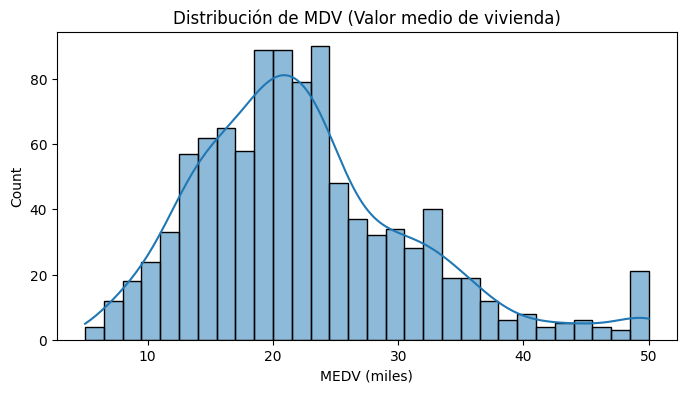

In [5]:
# Distribución
plt.figure(figsize=(8, 4))
sns.histplot(df[TARGET_COLUMN], bins=30, kde=True)
plt.title("Distribución de MDV (Valor medio de vivienda)")
plt.xlabel("MEDV (miles)")
plt.show()

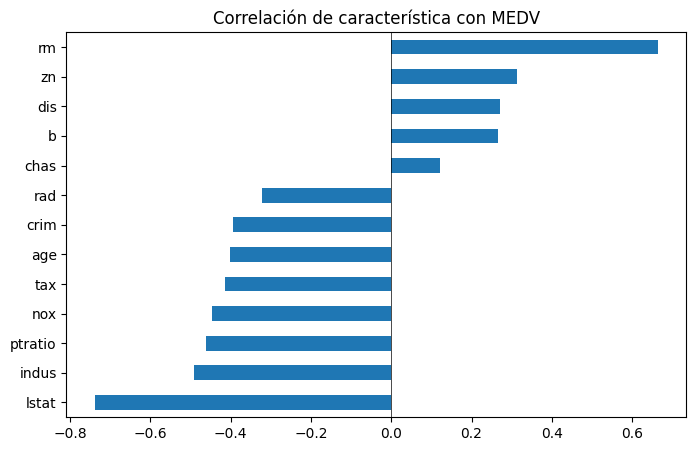

In [6]:
# Correlaciones
correlations = df[FEATURE_COLUMNS + [TARGET_COLUMN]].corr()[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values()
plt.figure(figsize=(8, 5))
correlations.plot(kind="barh")
plt.title("Correlación de característica con MEDV")
plt.axvline(0, color="black", linewidth=0.5)
plt.show()

## Preprocesamiento

In [7]:
# Preprocesador
def build_preprocessor():
    numeric_pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
    ])
    return ColumnTransformer(
        transformers=[("num", numeric_pipeline, FEATURE_COLUMNS)],
        remainder="drop",
        verbose_feature_names_out=False,
    )

preprocessor = build_preprocessor()
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_na

In [8]:
# Eliminar vacíos
df.dropna(axis=0, inplace=True)

# Seleccionar el conjunto de características
X = df[FEATURE_COLUMNS]
X_transformed = preprocessor.fit_transform(X)

print("Tamaño original:", X.shape)
print("Tamaño transformado:", X_transformed.shape)

print("Valores originales (:10)")
print(X.head(10))

print("Valores transformados (:10)")
print(X_transformed[:10])

Tamaño original: (776, 13)
Tamaño transformado: (776, 13)
Valores originales (:10)
       crim    zn  indus  chas    nox     rm    age     dis  rad    tax  \
0   0.00632  18.0   2.31   0.0  0.538  6.575   65.2  4.0900    1  296.0   
1   0.02731   0.0   7.07   0.0  0.469  6.421   78.9  4.9671    2  242.0   
2   0.02729   0.0   7.07   0.0  0.469  7.185   61.1  4.9671    2  242.0   
3   0.03237   0.0   2.18   0.0  0.458  6.998   45.8  6.0622    3  222.0   
5   0.02985   0.0   2.18   0.0  0.458  6.430   58.7  6.0622    3  222.0   
7   0.14455  12.5   7.87   0.0  0.524  6.172   96.1  5.9505    5  311.0   
8   0.21124  12.5   7.87   0.0  0.524  5.631  100.0  6.0821    5  311.0   
10  0.22489  12.5   7.87   0.0  0.524  6.377   94.3  6.3467    5  311.0   
11  0.11747  12.5   7.87   0.0  0.524  6.009   82.9  6.2267    5  311.0   
12  0.09378  12.5   7.87   0.0  0.524  5.889   39.0  5.4509    5  311.0   

    ptratio       b  lstat  
0      15.3  396.90   4.98  
1      17.8  396.90   9.14  
2   

In [9]:
# Verificar vacíos
X.isna().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
dtype: int64

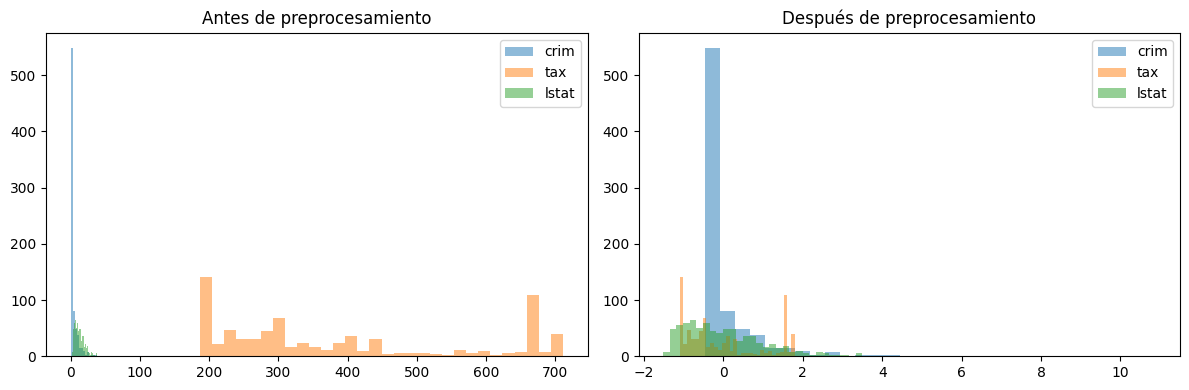

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample_features = ["crim", "tax", "lstat"]

for col in sample_features:
    axes[0].hist(df[col], bins=30, alpha=0.5, label=col)
axes[0].set_title("Antes de preprocesamiento")
axes[0].legend()

X_t_df = pd.DataFrame(X_transformed, columns=FEATURE_COLUMNS)
for col in sample_features:
    axes[1].hist(X_t_df[col], bins=30, alpha=0.5, label=col)
axes[1].set_title("Después de preprocesamiento")
axes[1].legend()

plt.tight_layout()
plt.show()